# Task 4e: 'Time of Day'

In this notebook, we are adding a new feature called **“Time of Day”** that tells us the time of day the event occured

It will try to discern the time of day the event occured and classify it into one of 4 categories: 
- "Morning"
- "Afternoon"
- "Evening"
- "Night"

If it is not discernable, it will return **"Unknown"**. 

In [12]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
haunted_places = pd.read_csv("../data/haunted_places.tsv", sep='\t')

In [14]:
# Function to extract and categorize time of day
def categorize_time_of_day(description):
    if pd.isna(description):
        return "Unknown"
    
    description = description.lower()
    
    # Check for specific times (e.g., "7pm", "3am")
    time_patterns = [
        (r'\b(\d{1,2}(?:am|pm))\b', 'Specific Time'),  # Matches times like "7pm" or "3am"
    ]
    
    for pattern, time_label in time_patterns:
        match = re.search(pattern, description)
        if match:
            time_str = match.group(1)
            # Convert specific times to categories
            if 'pm' in time_str:
                hour = int(time_str.replace('pm', ''))
                if 6 <= hour < 12:
                    return "Evening"
                elif hour == 12:
                    return "Noon"
                else:
                    return "Afternoon"
            elif 'am' in time_str:
                hour = int(time_str.replace('am', ''))
                if 6 <= hour < 12:
                    return "Morning"
                elif hour == 12:
                    return "Midnight"
                else:
                    return "Night"
    
    # Check for time-related keywords
    time_keywords = [
        ('morning', 'Morning'),
        ('sunrise', 'Morning'),
        ('dawn', 'Morning'),
        ('afternoon', 'Afternoon'),
        ('midday', 'Afternoon'),
        ('evening', 'Evening'),
        ('sunset', 'Evening'),
        ('dusk', 'Evening'),
        ('night', 'Night'),
        ('midnight', 'Night'),
        ('dark', 'Night'),
        ('early morning', 'Morning'),
        ('late night', 'Night'),
        ('late evening', 'Evening'),
        ('early evening', 'Evening'),
        ('early afternoon', 'Afternoon'),
        ('late afternoon', 'Afternoon'),
    ]
    
    for keyword, time_label in time_keywords:
        if keyword in description:
            return time_label
    
    # If no time is found, return "Unknown"
    return "Unknown"

# Apply function to create the 'Time of Day' column
haunted_places["Time of Day"] = haunted_places["description"].apply(categorize_time_of_day)

# Save the updated DataFrame back to a TSV file
haunted_places.to_csv("../data/haunted_places_updated.tsv", sep='\t', index=False)




In [40]:
haunted_places.to_csv("../data/haunted_places.tsv", sep='\t', index=False)


In [42]:
# Apply function to create the 'Time of Day' column
haunted_places["Time of Day"] = haunted_places["description"].apply(categorize_time_of_day)

# Count occurrences
time_counts = haunted_places['Time of Day'].value_counts()

# Total entries
total_entries = len(haunted_places)

# Reorder to put categories in logical time order
time_counts = time_counts.reindex(["Morning", "Afternoon", "Evening", "Night", "Unknown"], fill_value=0)

print(time_counts)


Time of Day
Morning       337
Afternoon      49
Evening       145
Night        3465
Unknown      6993
Name: count, dtype: int64


# Visualizations
Let's take a look at some of the results. 

The graph below lets us examine the **Time of Day Categories** within the entire dataset. Based on the graph, we have the following results: 
- Morning: 337 (**3.1%**)
- Afternoon: 49 (**0.4%**)
- Evening: 145 (**1.3%**)
- Night: 3465 (**31.5%**)
- Unknown: 6993 (**63.6%**) 


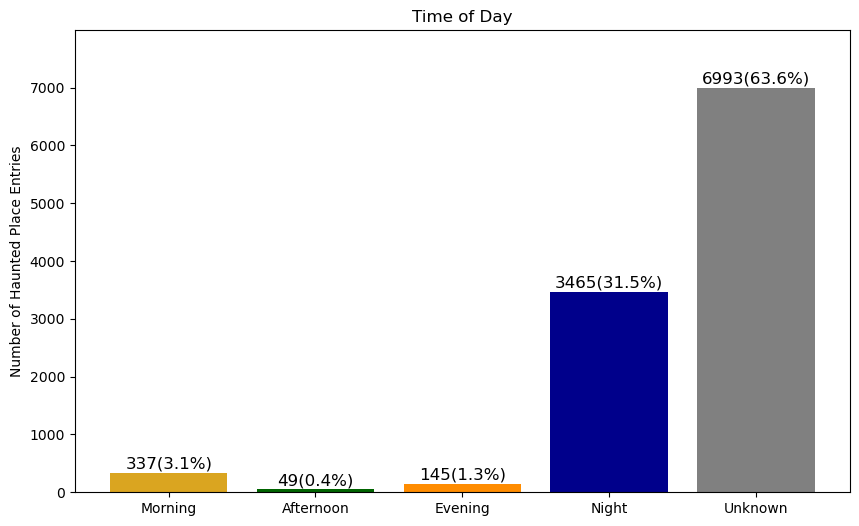

In [44]:
# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(time_counts.index, time_counts.values, color=['goldenrod', 'darkgreen', 'darkorange', 'darkblue', 'gray'])

# Add text (count + percentage) on top of each bar
for bar, count in zip(bars, time_counts):
    percentage = (count / total_entries) * 100
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,  # Adjust the +20 for spacing
             f'{count}\
({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=12, color='black')  # va='bottom' places text above


# Labels and title
plt.ylabel('Number of Haunted Place Entries')
plt.title('Time of Day')
plt.ylim(0, max(time_counts) + 1000)  # Adjust buffer for text

plt.show()